In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.regression.rolling import RollingOLS
import plotly.graph_objects as go
import plotly.express as px
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
def calculate_sortino_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    """
    Calculates the annualized Sortino Ratio.
    
    Args:
        returns (pd.Series): A Series of (typically daily) net returns.
        risk_free_rate (float): The annual risk-free rate (e.g., 0.05 for 5%).
        periods_per_year (int): Number of periods (e.g., 252 for daily).
    """
    if returns.empty:
        return 0.0

    # 1. Calculate periodic risk-free rate (this is our target)
    periodic_rfr = (1 + risk_free_rate) ** (1 / periods_per_year) - 1

    # 2. Calculate average return
    avg_return = returns.mean()

    # 3. Calculate downside deviation
    # Get all returns that are *below* the target (risk-free rate)
    diffs = returns - periodic_rfr
    downside_diffs = diffs[diffs < 0]
    
    if downside_diffs.empty:
        return 0.0 # No downside risk, can't calculate

    # Square the negative differences
    squared_downside = downside_diffs ** 2
    
    # Calculate the average of these squares (relative to *all* days)
    # This is the "Downside Variance"
    variance_downside = squared_downside.sum() / len(returns)

    # The square root is the "Downside Deviation"
    downside_std = np.sqrt(variance_downside)
    
    if downside_std == 0:
        return 0.0

    # 4. Calculate Sortino Ratio
    sortino_ratio = (avg_return - periodic_rfr) / downside_std
    
    # 5. Annualize it
    annualized_sortino = sortino_ratio * np.sqrt(periods_per_year)
    
    return annualized_sortino

In [3]:
def calculate_sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    """
    Calculates the annualized Sharpe Ratio for a returns stream.

    Args:
        returns (pd.Series): A Series of (typically daily) net returns.
        risk_free_rate (float): The annual risk-free rate (e.g., 0.05 for 5%).
        periods_per_year (int): Number of periods in a year
                                (e.g., 252 for daily, 52 for weekly).

    Returns:
        float: The annualized Sharpe Ratio.
    """
    if returns.std() == 0:
        # Handle zero-volatility case (e.g., no trades or constant returns)
        return 0.0

    # Calculate the per-period risk-free rate
    periodic_risk_free = (1 + risk_free_rate) ** (1 / periods_per_year) - 1

    # Calculate excess returns
    excess_returns = returns - periodic_risk_free

    # Calculate the Sharpe Ratio for the period
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns)

    # Annualize the Sharpe Ratio
    annualized_sharpe = sharpe_ratio * np.sqrt(periods_per_year)

    return annualized_sharpe

In [4]:
def flexible_backtest(
    data,
    target_col_name,
    price_col_name=None,
    pnl_col_name=None,
    input_type="price",
    strategy_type="state",
    row_shift=1,
    p_spread=0.0,
    return_type="log",
):
    """
    Performs a flexible backtest with three logic modes.
    
    Args:
        data (pd.DataFrame): DataFrame with price and signal.
        target_col_name (str): The name of the signal OR position column.
        price_col_name (str): Optional. The name of the price column. Required if input_type="price".
        pnl_col_name (str): Optional. The name of the column containing PNL/returns data. Required if input_type="pnl".
        input_type (str): "price" or "pnl". Determines which column to use for returns.
        strategy_type (str): The type of backtest to run:
            - 'positions': (Fast, Vectorized) Assumes target_col_name
                           IS the final desired position. Ignores row_shift.
            - 'state': (Fast, Vectorized) Assumes target_col_name is a
                       SIGNAL (1, -1, 0) and shifts it to get position.
            - 'event_hold': (Loop) Assumes signal is a "pulse" (1, -1, 0).
                            Holds position on 0. Max pos is 1 or -1.
            - 'event_pyramid': (Loop) Assumes signal is a "pulse" (1, -1, 0).
                               Adds to position on signal (1, 2, 3...).
        row_shift (int): The lag between signal generation and execution.
                         (Ignored if strategy_type='positions')
        p_spread (float): Cost (as a decimal) to apply per unit traded.
        return_type (str): "log" or "absolute". Determines how returns are calculated if input_type="price".
                           "log": np.log(price).diff()
                           "absolute": price.diff()
    
    Returns:
        pd.DataFrame: A new DataFrame with all backtest results.
    """
    
    # 1. --- Setup ---
    df = data.copy()
    
    # Validate inputs
    if price_col_name is not None and pnl_col_name is not None:
        raise ValueError("Please provide either price_col_name OR pnl_col_name, not both.")
    
    # Determine the "step_returns" (the return per unit for each step)
    if input_type == "pnl":
        if pnl_col_name is None:
            raise ValueError("pnl_col_name must be provided when input_type='pnl'.")
        df["step_returns"] = df[pnl_col_name]
    elif input_type == "price":
        if price_col_name is None:
            raise ValueError("price_col_name must be provided when input_type='price'.")
        
        if return_type == "log":
            df["step_returns"] = np.log(df[price_col_name]).diff()
        elif return_type == "absolute":
            df["step_returns"] = df[price_col_name].diff()
        else:
            raise ValueError(f"Unknown return_type: '{return_type}'. Must be 'log' or 'absolute'.")
    else:
        raise ValueError(f"Unknown input_type: '{input_type}'. Must be 'price' or 'pnl'.")
    
    # ========================================================================
    # 2. --- LOGIC PATH A: 'positions' (Vectorized, Pre-Calculated) ---
    # ========================================================================
    if strategy_type == "positions":
        # Assumes target_col_name *is* the final, aligned position column
        # No shift is applied.
        df["position"] = df[target_col_name]
        
        # Standard P&L and Cost Calculation
        df["strategy_returns"] = df["position"] * df["step_returns"]
        df["position_change"] = df["position"].diff().abs()
        df["slippage_cost"] = df["position_change"] * p_spread
        df["strategy_returns_net"] = df["strategy_returns"] - df["slippage_cost"]

    # ========================================================================
    # 2. --- LOGIC PATH B: 'state' (Vectorized) ---
    # ========================================================================
    elif strategy_type == "state":
        df["position"] = df[target_col_name].shift(row_shift)
        df["strategy_returns"] = df["position"] * df["step_returns"]
        df["position_change"] = df["position"].diff().abs()
        df["slippage_cost"] = df["position_change"] * p_spread
        df["strategy_returns_net"] = df["strategy_returns"] - df["slippage_cost"]

    # ========================================================================
    # 2. --- LOGIC PATH C: 'event_hold' (Loop-Based) ---
    # ========================================================================
    elif strategy_type == "event_hold":
        df["position"] = 0.0
        df["position_change"] = 0.0
        df["slippage_cost"] = 0.0
        df["strategy_returns_net"] = 0.0

        for i in range(row_shift, len(df)):
            signal = df[target_col_name].iloc[i - row_shift]
            yesterday_pos = df["position"].iloc[i - 1]

            # Determine Today's Position (Hold Logic)
            today_pos = yesterday_pos  # Default: Hold position

            if signal == 1:
                today_pos = 1  # Go long (or stay long)
            elif signal == -1:
                today_pos = -1  # Go short (or stay short)
            elif signal == 2:
                today_pos = 0
            # If signal is 0, today_pos remains yesterday_pos (hold)

            df.iloc[i, df.columns.get_loc("position")] = today_pos

            # Calculate P&L and Costs
            pos_change = abs(today_pos - yesterday_pos)
            cost = pos_change * p_spread
            gross_return = today_pos * df["step_returns"].iloc[i]
            net_return = gross_return - cost

            df.iloc[i, df.columns.get_loc("position_change")] = pos_change
            df.iloc[i, df.columns.get_loc("slippage_cost")] = cost
            df.iloc[i, df.columns.get_loc("strategy_returns_net")] = net_return

    # ========================================================================
    # 2. --- LOGIC PATH D: 'event_pyramid' (Loop-Based) ---
    # ========================================================================
    elif strategy_type == "event_pyramid":
        df["position"] = 0.0
        df["position_change"] = 0.0
        df["slippage_cost"] = 0.0
        df["strategy_returns_net"] = 0.0

        for i in range(row_shift, len(df)):
            signal = df[target_col_name].iloc[i - row_shift]
            yesterday_pos = df["position"].iloc[i - 1]

            # Determine Today's Position (Pyramiding Logic)
            today_pos = yesterday_pos # Default: Hold

            if signal == 1:
                if yesterday_pos < 0:
                    today_pos = 1  # Flip from short to 1 long
                else:
                    today_pos = yesterday_pos + 1  # Add to long
            elif signal == -1:
                if yesterday_pos > 0:
                    today_pos = -1  # Flip from long to 1 short
                else:
                    today_pos = yesterday_pos - 1  # Add to short
            elif signal == 2:
                today_pos = 0 # Close all positions
            
            df.iloc[i, df.columns.get_loc("position")] = today_pos

            # Calculate P&L and Costs
            pos_change = abs(today_pos - yesterday_pos)
            cost = pos_change * p_spread
            gross_return = today_pos * df["step_returns"].iloc[i]
            net_return = gross_return - cost

            df.iloc[i, df.columns.get_loc("position_change")] = pos_change
            df.iloc[i, df.columns.get_loc("slippage_cost")] = cost
            df.iloc[i, df.columns.get_loc("strategy_returns_net")] = net_return
    
    else:
        raise ValueError(
            f"Unknown strategy_type: '{strategy_type}'. "
            "Must be 'positions', 'state', 'event_hold', or 'event_pyramid'."
        )

    # 3. --- Post-Processing (Common to all) ---
    if return_type == "log" and pnl_col_name is None:
        df["cumulative_strategy"] = df["strategy_returns_net"].cumsum().apply(np.exp)
        df["cumulative_buy_and_hold"] = df["step_returns"].fillna(0).cumsum().apply(np.exp)
    else:
        df["cumulative_strategy"] = df["strategy_returns_net"].cumsum()
        df["cumulative_buy_and_hold"] = df["step_returns"].fillna(0).cumsum()

    # Clean up
    # We must slice *after* all .diff() and .shift() calls
    # results = df.iloc[row_shift:].copy()
    results = df.copy()
    
    # Drop initial rows that have NaNs from calculations
    # 'position' can be 0, so we check returns columns
    results.dropna(subset=["step_returns", "strategy_returns_net"], inplace=True)

    return results


In [13]:
def calculate_cagr(cumulative_returns, periods_per_year=252):
    """
    Calculates the Compound Annual Growth Rate (CAGR).
    
    Args:
        cumulative_returns (pd.Series): A Series of cumulative returns (e.g., 1.0 -> 1.2 -> 1.5)
        periods_per_year (int): Number of periods (e.g., 252 for daily)
    """
    if cumulative_returns.empty:
        return 0.0

    # Get the total number of periods in the backtest
    total_periods = len(cumulative_returns)
    
    # Calculate total years
    total_years = total_periods / periods_per_year
    
    # Get start and end values
    start_value = cumulative_returns.iloc[0]
    end_value = cumulative_returns.iloc[-1]
    
    # Calculate CAGR
    cagr = (end_value / start_value) ** (1 / total_years) - 1
    
    return cagr

def calculate_max_drawdown(cumulative_returns):
    """
    Calculates the Maximum Drawdown (MDD).
    
    Args:
        cumulative_returns (pd.Series): A Series of cumulative returns (e.g., 1.0 -> 1.2 -> 1.5)
    """
    if cumulative_returns.empty:
        return 0.0
        
    # 1. Calculate the running maximum
    running_max = cumulative_returns.cummax()
    
    # 2. Calculate drawdown (percentage drop from running max)
    # Drawdown = (Current Value - Running Max) / Running Max
    drawdown = (cumulative_returns - running_max) / running_max
    
    # 3. Get the minimum (worst) drawdown
    max_drawdown = drawdown.min()
    
    return max_drawdown # Will be a negative number (e.g., -0.25 for 25%)

In [14]:
def show_backtest_report(results, risk_free_rate=0.02):
    """
    Takes a results DataFrame and prints all stats and plots.
    """
    if results is None or results.empty:
        print("Cannot show report: Backtest results are empty.")
        return
        
    # --- 1. Calculate All Key Stats ---
    net_returns_series = results['strategy_returns_net']
    cumulative_returns_series = results['cumulative_strategy']
    
    # Define periods
    periods_per_year = 252 # Assuming daily data
    
    # Calculate metrics
    sharpe = calculate_sharpe_ratio(
        net_returns_series, 
        risk_free_rate=risk_free_rate, 
        periods_per_year=periods_per_year
    )
    sortino = calculate_sortino_ratio(
        net_returns_series,
        risk_free_rate=risk_free_rate,
        periods_per_year=periods_per_year
    )
    cagr = calculate_cagr(
        cumulative_returns_series, 
        periods_per_year=periods_per_year
    )
    max_drawdown = calculate_max_drawdown(cumulative_returns_series)
    
    # Calmar Ratio (handle division by zero if MDD is 0)
    calmar = 0.0
    if max_drawdown != 0:
        calmar = cagr / abs(max_drawdown) # Use absolute value of MDD

    # --- 2. Print the Report ---
    print("--- Backtest Performance Report ---")
    print(f"Annualized Sharpe Ratio: {sharpe: .4f}")
    print(f"Annualized Sortino Ratio: {sortino: .4f}")
    print(f"Annualized Return (CAGR): {cagr: .2%}")
    print(f"Max Drawdown (MDD): {max_drawdown: .2%}")
    print(f"Calmar Ratio (CAGR/MDD): {calmar: .4f}")
    print("---------------------------------")

    # --- 2. Plot 1: P&L Curve ---
    print("Displaying Plot 1: Cumulative P&L")
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=results.index, y=results['cumulative_strategy'],
                             mode='lines', name='Strategy (Net)'))
    fig.add_trace(go.Scatter(x=results.index, y=results['cumulative_buy_and_hold'],
                             mode='lines', name='Buy and Hold', line=dict(color='grey', dash='dash')))
    fig.update_layout(title='Strategy vs. Buy and Hold',
                      yaxis_title='Cumulative Returns',
                      hovermode='x unified')
    fig.show()

    # --- 3. Plot 2: Position Size ---
    print("Displaying Plot 2: Position Size")
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=results.index, y=results['position'],
                             mode='lines', name='Position Size',
                             line=dict(shape='hv'))) # 'hv' makes it a step-plot
    fig2.update_layout(title='Position Over Time',
                       yaxis_title='Number of Units',
                       hovermode='x unified')
    fig2.show()

    # --- 4. Plot 3: Daily PNL (Bar Chart) ---
    print("Displaying Plot 3: Daily PNL with Average")
    results['pnl_color'] = ['green' if x > 0 else 'red' for x in results['strategy_returns_net']]
    fig3 = go.Figure()
    fig3.add_trace(go.Bar(
        x=results.index,
        y=results['strategy_returns_net'], 
        name='Daily PNL',
        marker_color=results['pnl_color']
    ))
    avg_pnl = results['strategy_returns_net'].mean()
    fig3.add_hline(
        y=avg_pnl, 
        line_dash="dash", 
        line_color="black",
        annotation_text=f"Average PNL: {avg_pnl:.5f}",
        annotation_position="bottom right",
        annotation_font=dict(color="black")
    )
    fig3.update_layout(
        title='Daily Strategy PNL (Net) with Average',
        yaxis_title='Net Log Return',
        xaxis_title='Date'
    )
    fig3.show()

    # --- 5. Plot 4: Daily PNL Distribution ---
    print("Displaying Plot 4: PNL Distribution")
    fig4 = px.histogram(
        results, 
        x='strategy_returns_net',
        nbins=100,
        title='Distribution of Daily PNL'
    )
    fig4.update_layout(
        xaxis_title='Net Log Return (Daily PNL)',
        yaxis_title='Frequency (Count of Days)'
    )
    fig4.show()


Found 86 events where USDMXN=X gained > 1.0% in a week.


C:\Users\gui_k\AppData\Local\Temp\ipykernel_12484\477424785.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)


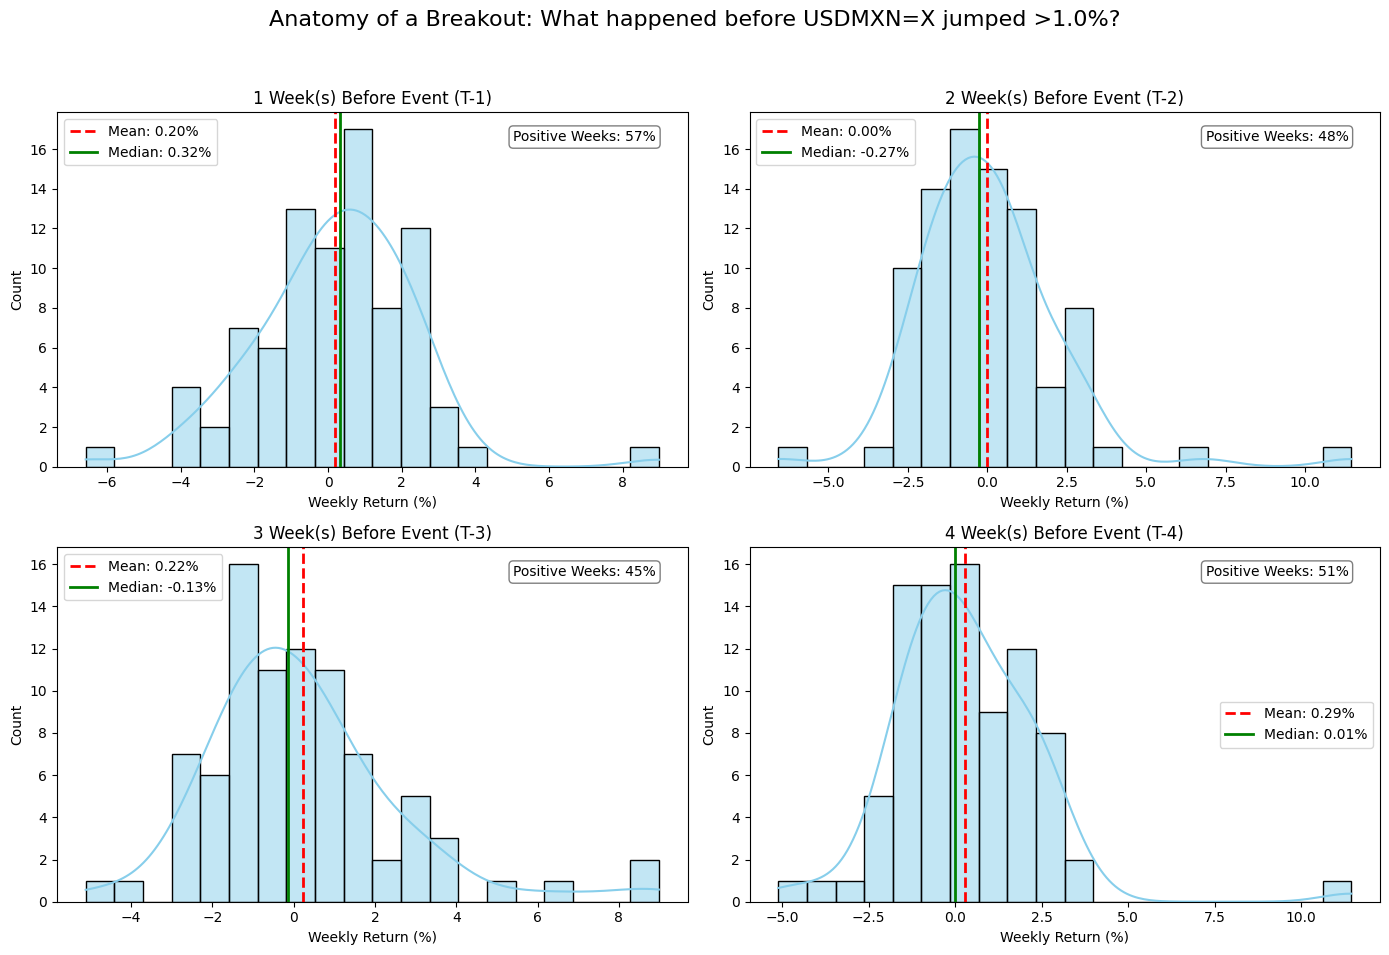


--- Summary Statistics of Prior Weeks ---
Price  Week_Minus_1  Week_Minus_2  Week_Minus_3  Week_Minus_4
count   8600.000000   8600.000000   8600.000000   8600.000000
mean       0.196379      0.001292      0.220823      0.293195
std        2.147813      2.276869      2.374858      2.101149
min       -6.582775     -6.582775     -5.112392     -5.112392
25%       -0.918697     -1.240152     -1.219239     -1.054634
50%        0.321046     -0.269460     -0.130577      0.009267
75%        1.583640      0.876709      1.164055      1.580857
max        8.981698     11.451495      8.981698     11.451495


In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETTINGS
# ==========================================
TICKER = "USDMXN=X"       # Try: "BTC-USD", "EURUSD=X", "SPY", "NVDA"
TARGET_MOVE = 0.01        # We are looking for weeks with > +3% gain
START_DATE = "2018-01-01" # 5+ years of data is best for stats
END_DATE = "2025-01-01"

# ==========================================
# 2. DATA ENGINE
# ==========================================
print(f"Downloading data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)

# Clean multi-index if necessary
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Weekly Returns
df['Return'] = df['Close'].pct_change()

# Create "Lag" Columns (The past behavior)
# T-1 means "1 week before", T-2 means "2 weeks before"
for i in [1, 2, 3, 4]:
    df[f'Week_Minus_{i}'] = df['Return'].shift(i)

# ==========================================
# 3. THE FILTER (The "Condition")
# ==========================================
# We only want to study the weeks where the "Target Move" happened
# You can change this to look for drops (<= -0.03) or ranges
event_df = df[df['Return'] >= TARGET_MOVE].dropna()

print(f"\nFound {len(event_df)} events where {TICKER} gained > {TARGET_MOVE*100}% in a week.")

# ==========================================
# 4. VISUALIZATION (The Distributions)
# ==========================================
if len(event_df) < 5:
    print("Not enough data points to plot distributions. Try a smaller threshold or longer date range.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Anatomy of a Breakout: What happened before {TICKER} jumped >{TARGET_MOVE*100}%?", fontsize=16)
    
    axes = axes.flatten()

    for i, ax in zip([1, 2, 3, 4], axes):
        col_name = f'Week_Minus_{i}'
        data = event_df[col_name] * 100  # Convert to percentage for readability
        
        # Plot Histogram with Kernel Density Estimate (KDE)
        sns.histplot(data, bins=20, kde=True, ax=ax, color='skyblue', edgecolor='black')
        
        # Calculate Stats
        avg = data.mean()
        med = data.median()
        win_rate = (data > 0).mean() * 100
        
        # Draw Lines
        ax.axvline(avg, color='red', linestyle='--', linewidth=2, label=f"Mean: {avg:.2f}%")
        ax.axvline(med, color='green', linestyle='-', linewidth=2, label=f"Median: {med:.2f}%")
        
        # Formatting
        ax.set_title(f"{i} Week(s) Before Event (T-{i})")
        ax.set_xlabel("Weekly Return (%)")
        ax.legend()
        
        # Add text box with "Win Rate" (Positivity)
        stats_text = f"Positive Weeks: {win_rate:.0f}%"
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ==========================================
# 5. STATISTICAL SUMMARY
# ==========================================
print("\n--- Summary Statistics of Prior Weeks ---")
summary = event_df[[f'Week_Minus_{i}' for i in range(1, 5)]].describe()
print(summary * 100) # Print in percentage

C:\Users\gui_k\AppData\Local\Temp\ipykernel_12484\3897318994.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)


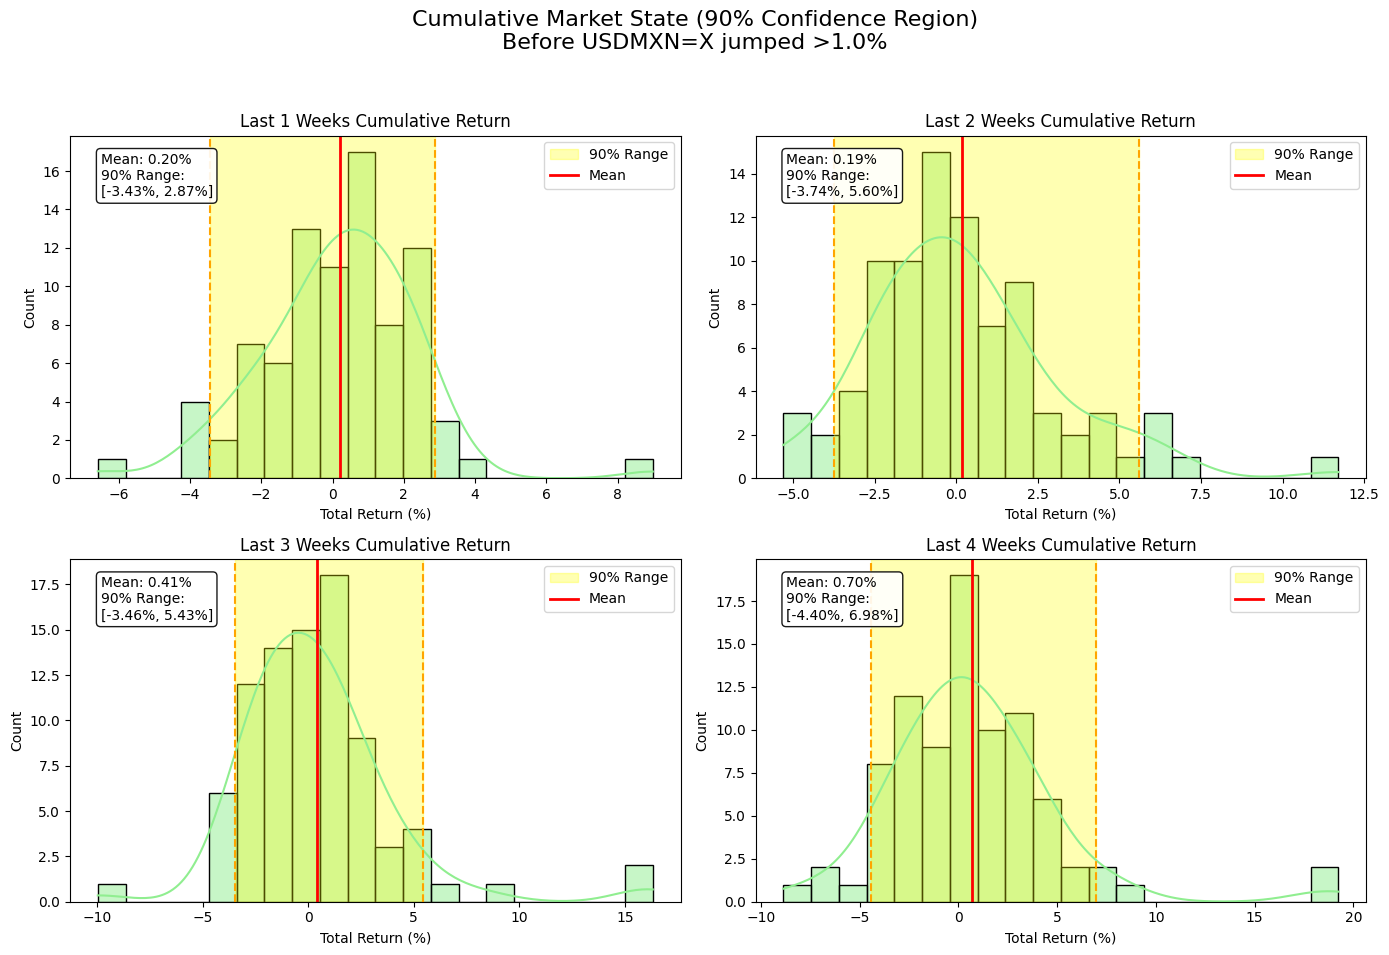

In [20]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETTINGS
# ==========================================
TICKER = "USDMXN=X"       
TARGET_MOVE = 0.01
START_DATE = "2018-01-01" 
END_DATE = "2025-01-01"
CONFIDENCE_LEVEL = 0.90   # 90% Confidence Interval

# ==========================================
# 2. DATA ENGINE (Same as before)
# ==========================================
print(f"Downloading data for {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Cumulative Returns
for i in [1, 2, 3, 4]:
    df[f'Cum_Ret_{i}wk'] = df['Close'].pct_change(periods=i).shift(1)

df['Current_Return'] = df['Close'].pct_change()

# Filter for the Event
event_df = df[df['Current_Return'] >= TARGET_MOVE].dropna()

# ==========================================
# 3. PLOTTING WITH CONFIDENCE REGIONS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Cumulative Market State ({CONFIDENCE_LEVEL*100:.0f}% Confidence Region)\nBefore {TICKER} jumped >{TARGET_MOVE*100}%", fontsize=16)

axes = axes.flatten()

for i, ax in zip([1, 2, 3, 4], axes):
    col_name = f'Cum_Ret_{i}wk'
    data = event_df[col_name] * 100 
    
    # 1. Plot Histogram
    sns.histplot(data, bins=20, kde=True, ax=ax, color='lightgreen', edgecolor='black')
    
    # 2. CALCULATE CONFIDENCE INTERVAL (Quantiles)
    # For 90% CI, we want the 5th percentile to 95th percentile
    lower_quantile = (1 - CONFIDENCE_LEVEL) / 2  # e.g., 0.05
    upper_quantile = 1 - lower_quantile          # e.g., 0.95
    
    ci_lower = data.quantile(lower_quantile)
    ci_upper = data.quantile(upper_quantile)
    
    # 3. ADD SHADED REGION (The "Confidence Line Region")
    ax.axvspan(ci_lower, ci_upper, color='yellow', alpha=0.3, label=f'{CONFIDENCE_LEVEL*100:.0f}% Range')
    
    # 4. Add Vertical Lines for the bounds
    ax.axvline(ci_lower, color='orange', linestyle='--', linewidth=1.5)
    ax.axvline(ci_upper, color='orange', linestyle='--', linewidth=1.5)
    
    # Add Mean line for reference
    mean_val = data.mean()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label='Mean')

    # Formatting
    ax.set_title(f"Last {i} Weeks Cumulative Return")
    ax.set_xlabel("Total Return (%)")
    ax.legend(loc='upper right')
    
    # Add Text Box with the exact values
    stats_text = (f"Mean: {mean_val:.2f}%\n"
                  f"90% Range:\n"
                  f"[{ci_lower:.2f}%, {ci_upper:.2f}%]")
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\gui_k\AppData\Local\Temp\ipykernel_12484\623078920.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)


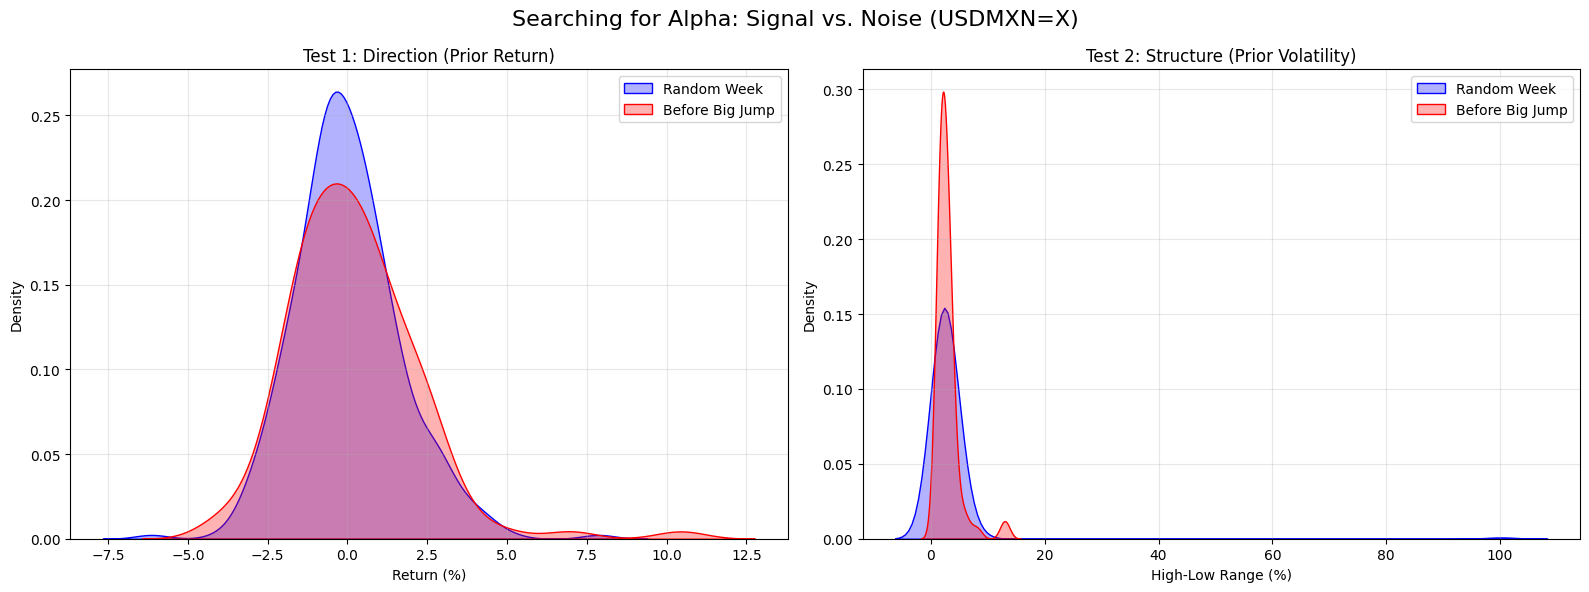

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. SETTINGS
# ==========================================
TICKER = "USDMXN=X"       
TARGET_MOVE = 0.01        # The "Big Jump" (>1%)
START_DATE = "2015-01-01" 
END_DATE = "2024-01-01"

# ==========================================
# 2. DATA PREP
# ==========================================
df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Features (What we are testing)
# Let's test "Volatility" (High-Low range) vs "Return" (Close-Close)
df['Feature_Return'] = df['Close'].pct_change()
df['Feature_Volatility'] = (df['High'] - df['Low']) / df['Open']

# Shift features to T-1 (The week BEFORE)
df['Prior_Return'] = df['Feature_Return'].shift(1)
df['Prior_Volatility'] = df['Feature_Volatility'].shift(1)

# Define Target
df['Next_Week_Move'] = df['Close'].pct_change()
df['Is_Big_Jump'] = df['Next_Week_Move'] >= TARGET_MOVE

df.dropna(inplace=True)

# Split Data
event_weeks = df[df['Is_Big_Jump'] == True]   # The Signal
boring_weeks = df[df['Is_Big_Jump'] == False] # The Noise

# ==========================================
# 3. THE ALPHA TEST (Overlaid Plots)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Searching for Alpha: Signal vs. Noise ({TICKER})", fontsize=16)

# --- PLOT 1: Does DIRECTION matter? ---
sns.kdeplot(data=boring_weeks['Prior_Return']*100, ax=axes[0], color='blue', fill=True, alpha=0.3, label='Random Week')
sns.kdeplot(data=event_weeks['Prior_Return']*100, ax=axes[0], color='red', fill=True, alpha=0.3, label='Before Big Jump')
axes[0].set_title("Test 1: Direction (Prior Return)")
axes[0].set_xlabel("Return (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- PLOT 2: Does VOLATILITY matter? ---
sns.kdeplot(data=boring_weeks['Prior_Volatility']*100, ax=axes[1], color='blue', fill=True, alpha=0.3, label='Random Week')
sns.kdeplot(data=event_weeks['Prior_Volatility']*100, ax=axes[1], color='red', fill=True, alpha=0.3, label='Before Big Jump')
axes[1].set_title("Test 2: Structure (Prior Volatility)")
axes[1].set_xlabel("High-Low Range (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
TICKER = "USDMXN=X"       
TARGET_MOVE = -0.01        # The "Big Jump" (>1%)
START_DATE = "2020-01-01" 
END_DATE = "2025-01-01"

df = yf.download(TICKER, start=START_DATE, end=END_DATE, interval="1wk", progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

C:\Users\gui_k\AppData\Local\Temp\ipykernel_23056\2288148815.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True



In [23]:
df["prev_close"] = df["Close"].shift(1)
df["pct_change"] = (df["Close"] - df["prev_close"])/df["prev_close"]
df["open_close_diff"] = df["Open"] - df["Close"]
df["enter"] = 0
df["enter"] = (df["pct_change"] < TARGET_MOVE).astype(int)
# df["enter"] = df["enter"].shift(1)

In [27]:
df.index = pd.to_datetime(df.index)
filtered_df = df.copy()
# filtered_df = filtered_df.loc['2021-01-01':]
print("Running backtest...")
results = flexible_backtest(
    data=filtered_df,
    target_col_name="enter",
    price_col_name="Close",
    input_type="price",
    row_shift=1,  # Your 2-day manual lag
    p_spread=0.001,
    strategy_type='state'
)  # 0.01% cost
show_backtest_report(results)

Running backtest...
--- Backtest Performance Report ---
Annualized Sharpe Ratio:  0.9531
Annualized Sortino Ratio:  1.7568
Annualized Return (CAGR):  15.71%
Max Drawdown (MDD): -9.13%
Calmar Ratio (CAGR/MDD):  1.7217
---------------------------------
Displaying Plot 1: Cumulative P&L


Displaying Plot 2: Position Size


Displaying Plot 3: Daily PNL with Average


Displaying Plot 4: PNL Distribution


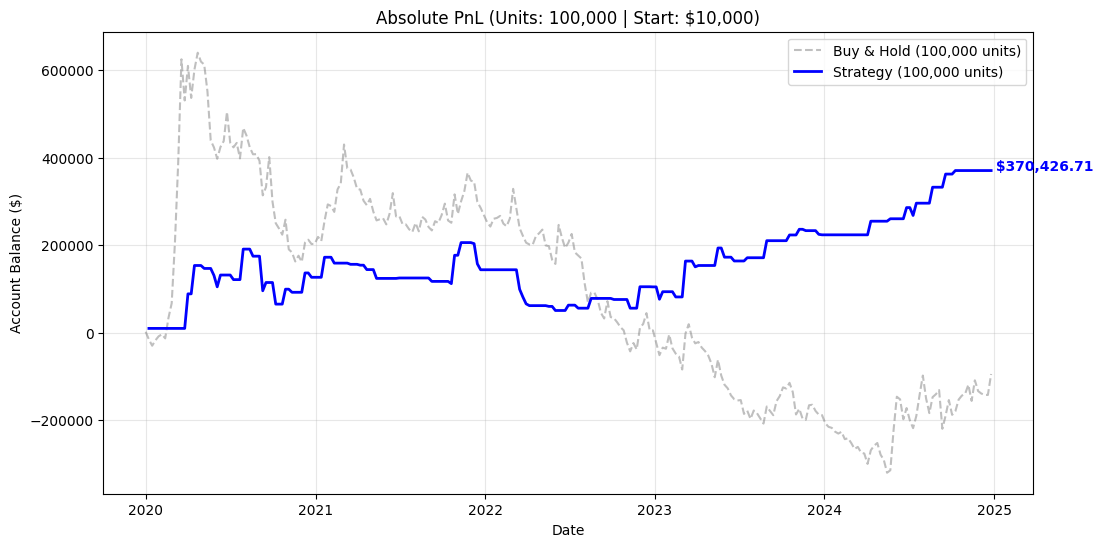

In [71]:
import matplotlib.pyplot as plt

# 1. SETUP: Capital & Position Size
INITIAL_CAPITAL = 10000   # Starting Cash
UNITS = 100000            # Position Size (e.g., 1 Standard Lot in FX)

# 2. CALCULATE: Price Difference (The "Pips" or "Points")
# If you are Long, Profit = Close - Open
# (Note: You mentioned 'open_low_diff' earlier, but for PnL it's usually Close - Open)
df["price_diff"] = df["Close"] - df["Open"]

# 3. CALCULATE: Strategy PnL ($)
# Logic: (Price Move) * (1 or 0 Signal) * (Number of Units)
df["strategy_pnl_dollar"] = df["price_diff"] * df["enter"] * UNITS

# 4. CALCULATE: Cumulative Equity
# We use .cumsum() (Summation), NOT .cumprod()
df["Strategy_Equity"] = INITIAL_CAPITAL + df["strategy_pnl_dollar"].cumsum()

# --- Optional: Buy & Hold Comparison (Assuming you held UNITS the whole time) ---
df["bh_pnl_dollar"] = df["price_diff"] * UNITS
df["BuyHold_Equity"] = INITIAL_CAPITAL + df["bh_pnl_dollar"].cumsum()

# 5. PLOTTING
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["BuyHold_Equity"], label=f"Buy & Hold ({UNITS:,} units)", color='gray', alpha=0.5, linestyle='--')
plt.plot(df.index, df["Strategy_Equity"], label=f"Strategy ({UNITS:,} units)", color='blue', linewidth=2)

plt.title(f"Absolute PnL (Units: {UNITS:,} | Start: ${INITIAL_CAPITAL:,})")
plt.ylabel("Account Balance ($)")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)

# Show final number
final_val = df["Strategy_Equity"].iloc[-1]
plt.text(df.index[-1], final_val, f" ${final_val:,.2f}", color='blue', fontweight='bold')

plt.show()